# Missing data
The options are:
- Leaving it in (May be setting a value that allows to operate the column, like 0, or keeping in mind that the column has N/A values)
- Filling with some value based off domain knowledge
- Drop rows or columns to get rid of them



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../../jupyter_notebooks/DATA/Ames_outliers_removed.csv')
df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2922,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2923,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,AllPub,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2924,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2925,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2927 entries, 0 to 2926
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2927 non-null   int64  
 1   MS SubClass      2927 non-null   int64  
 2   MS Zoning        2927 non-null   object 
 3   Lot Frontage     2437 non-null   float64
 4   Lot Area         2927 non-null   int64  
 5   Street           2927 non-null   object 
 6   Alley            198 non-null    object 
 7   Lot Shape        2927 non-null   object 
 8   Land Contour     2927 non-null   object 
 9   Utilities        2927 non-null   object 
 10  Lot Config       2927 non-null   object 
 11  Land Slope       2927 non-null   object 
 12  Neighborhood     2927 non-null   object 
 13  Condition 1      2927 non-null   object 
 14  Condition 2      2927 non-null   object 
 15  Bldg Type        2927 non-null   object 
 16  House Style      2927 non-null   object 
 17  Overall Qual  

In [4]:
df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df = df.drop("PID", axis=1)

In [6]:
len(df.columns)

80

In [7]:
df.isnull().sum()

MS SubClass         0
MS Zoning           0
Lot Frontage      490
Lot Area            0
Street              0
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 80, dtype: int64

In [8]:
def percent_missing (df):
    percent_nan = 100 * df.isnull().sum() / len(df)
    percent_nan = percent_nan[percent_nan > 0].sort_values()
    return percent_nan

In [9]:
percent_nan = percent_missing(df)
percent_nan

Total Bsmt SF      0.034165
Bsmt Unf SF        0.034165
BsmtFin SF 2       0.034165
Electrical         0.034165
BsmtFin SF 1       0.034165
Garage Area        0.034165
Garage Cars        0.034165
Bsmt Full Bath     0.068329
Bsmt Half Bath     0.068329
Mas Vnr Area       0.785787
Bsmt Qual          2.733174
Bsmt Cond          2.733174
BsmtFin Type 1     2.733174
BsmtFin Type 2     2.767339
Bsmt Exposure      2.835668
Garage Type        5.363854
Garage Qual        5.432183
Garage Finish      5.432183
Garage Cond        5.432183
Garage Yr Blt      5.432183
Lot Frontage      16.740690
Fireplace Qu      48.582166
Mas Vnr Type      60.642296
Fence             80.457807
Alley             93.235395
Misc Feature      96.412709
Pool QC           99.590024
dtype: float64

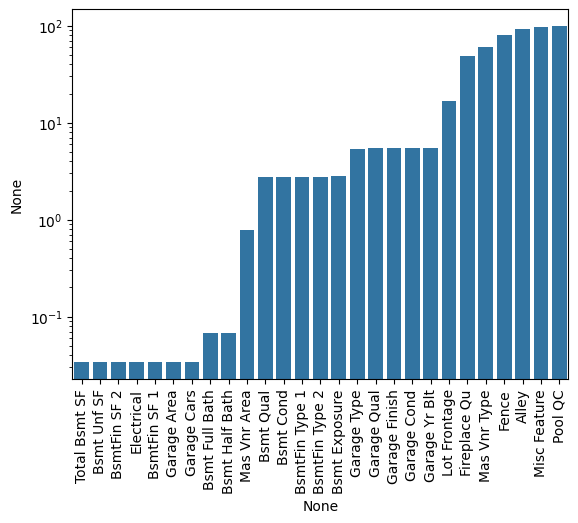

In [10]:
#plot the missing %
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.yscale('log')
plt.xticks(rotation=90);

## Choose what to do with missing data

In the case when only a couple of rows miss data for a column, it may make sense to just drop the row, if the column is important (high correlation with the label to predict). In the previous graph we can se that there are seven columns which are missing in only one row each (might repeat row among them). Let's analyze them to see if they are missing from the same row or each column is missing from different rows.

In [11]:
# let's see how many are missing data under 1%
percent_nan[percent_nan < 1]

Total Bsmt SF     0.034165
Bsmt Unf SF       0.034165
BsmtFin SF 2      0.034165
Electrical        0.034165
BsmtFin SF 1      0.034165
Garage Area       0.034165
Garage Cars       0.034165
Bsmt Full Bath    0.068329
Bsmt Half Bath    0.068329
Mas Vnr Area      0.785787
dtype: float64

### Filling or dropping data based on rows

In [12]:
# Let's see what data are present in the row where "Electrical" is missing.
df[df['Electrical'].isnull()].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 1576 to 1576
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      1 non-null      int64  
 1   MS Zoning        1 non-null      object 
 2   Lot Frontage     1 non-null      float64
 3   Lot Area         1 non-null      int64  
 4   Street           1 non-null      object 
 5   Alley            0 non-null      object 
 6   Lot Shape        1 non-null      object 
 7   Land Contour     1 non-null      object 
 8   Utilities        1 non-null      object 
 9   Lot Config       1 non-null      object 
 10  Land Slope       1 non-null      object 
 11  Neighborhood     1 non-null      object 
 12  Condition 1      1 non-null      object 
 13  Condition 2      1 non-null      object 
 14  Bldg Type        1 non-null      object 
 15  House Style      1 non-null      object 
 16  Overall Qual     1 non-null      int64  
 17  Overall Cond     1 

So for the row with 'Electrical' null, it also have some other columns with null too. Dropping this row will get rid of more than one null value.
Let's see about 'Garage Cars'.

In [13]:
df[df['Garage Cars'].isnull()].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 2233 to 2233
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      1 non-null      int64  
 1   MS Zoning        1 non-null      object 
 2   Lot Frontage     1 non-null      float64
 3   Lot Area         1 non-null      int64  
 4   Street           1 non-null      object 
 5   Alley            0 non-null      object 
 6   Lot Shape        1 non-null      object 
 7   Land Contour     1 non-null      object 
 8   Utilities        1 non-null      object 
 9   Lot Config       1 non-null      object 
 10  Land Slope       1 non-null      object 
 11  Neighborhood     1 non-null      object 
 12  Condition 1      1 non-null      object 
 13  Condition 2      1 non-null      object 
 14  Bldg Type        1 non-null      object 
 15  House Style      1 non-null      object 
 16  Overall Qual     1 non-null      int64  
 17  Overall Cond     1 

It has a dozen null values. This is also a good candidate to be dropped.

Let's drop those two rows: the one missing 'Electrical' and the one missing 'Garage Cars'. Then we'll take a look at how many null are remaining.

In [14]:
# drop rows with null values in columns ['Electrical', 'Garage Cars']
df=df.dropna(axis=0,subset=['Electrical', 'Garage Cars'])

In [15]:
# Recalculate the % of null values
percent_nan = percent_missing(df)
percent_nan

Total Bsmt SF      0.034188
Bsmt Unf SF        0.034188
BsmtFin SF 2       0.034188
BsmtFin SF 1       0.034188
Bsmt Full Bath     0.068376
Bsmt Half Bath     0.068376
Mas Vnr Area       0.786325
BsmtFin Type 1     2.735043
Bsmt Qual          2.735043
Bsmt Cond          2.735043
BsmtFin Type 2     2.769231
Bsmt Exposure      2.837607
Garage Type        5.367521
Garage Qual        5.401709
Garage Yr Blt      5.401709
Garage Finish      5.401709
Garage Cond        5.401709
Lot Frontage      16.752137
Fireplace Qu      48.547009
Mas Vnr Type      60.615385
Fence             80.478632
Alley             93.230769
Misc Feature      96.410256
Pool QC           99.589744
dtype: float64

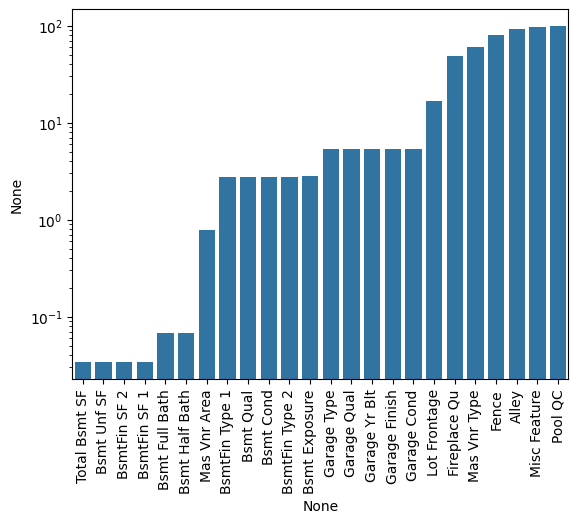

In [16]:
# we have less rows with one column missing. Let's plot it.
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.yscale('log')
plt.xticks(rotation=90);

We are down to 4 features with only one row at null (from seven initially).
Let's briefly look into basement data

In [17]:
df[df['Total Bsmt SF'].isnull()].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 1341 to 1341
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      1 non-null      int64  
 1   MS Zoning        1 non-null      object 
 2   Lot Frontage     1 non-null      float64
 3   Lot Area         1 non-null      int64  
 4   Street           1 non-null      object 
 5   Alley            0 non-null      object 
 6   Lot Shape        1 non-null      object 
 7   Land Contour     1 non-null      object 
 8   Utilities        1 non-null      object 
 9   Lot Config       1 non-null      object 
 10  Land Slope       1 non-null      object 
 11  Neighborhood     1 non-null      object 
 12  Condition 1      1 non-null      object 
 13  Condition 2      1 non-null      object 
 14  Bldg Type        1 non-null      object 
 15  House Style      1 non-null      object 
 16  Overall Qual     1 non-null      int64  
 17  Overall Cond     1 

# Fixing data Based on Rows

So this one is the one having all the other Bsmt null values.

In the description of the basement features is specified that NA means there is no basement in the property. So: using this domain knowledge, let's keep this row of data, filling in the NA values with meaningful data:
- measurements will be filled with 0, meaning e.g. 0 square feet of basement
- categorical columns will be filled with string 'None'

In [19]:
df[df['Bsmt Full Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


In [20]:
# BSMT Numeric columns
bsmt_num_cols = ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath']
df[bsmt_num_cols] = df[bsmt_num_cols].fillna(0)

# BSMT String columns
bsmt_str_cols = ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']
df[bsmt_str_cols] = df[bsmt_str_cols].fillna('None')

In [21]:
# check that the Bsmt Full Bath null disappeared
df[df['Bsmt Full Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice


In [22]:
# Recalculate the % of null values
percent_nan = percent_missing(df)
percent_nan

Mas Vnr Area      0.786325
Garage Type       5.367521
Garage Yr Blt     5.401709
Garage Finish     5.401709
Garage Cond       5.401709
Garage Qual       5.401709
Lot Frontage     16.752137
Fireplace Qu     48.547009
Mas Vnr Type     60.615385
Fence            80.478632
Alley            93.230769
Misc Feature     96.410256
Pool QC          99.589744
dtype: float64

The features with only one row null have disappeared. Let's plot it.

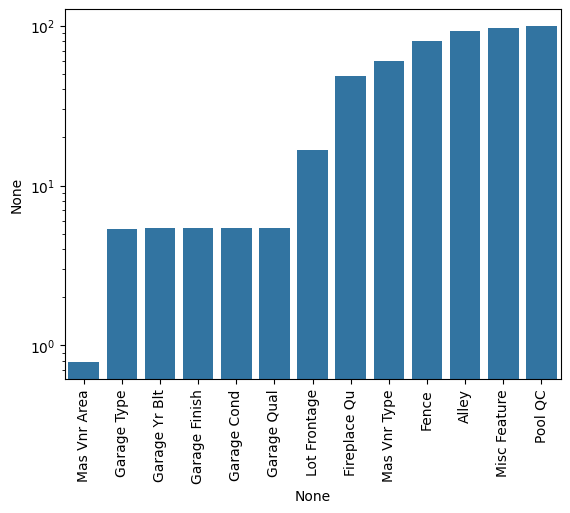

In [23]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.yscale('log')
plt.xticks(rotation=90);

In [24]:
df[df['Mas Vnr Area'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
55,60,RL,NaN,7851,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,216500
484,60,RL,NaN,12891,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,257500
517,20,FV,90.0,7993,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,10,2009,New,Partial,225000
538,20,RL,67.0,10083,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2009,WD,Normal,184900
867,60,RL,70.0,8749,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,11,2009,WD,Normal,198500
1095,60,RL,NaN,7750,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2008,WD,Normal,176000
1119,20,RL,87.0,10037,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,8,2008,WD,Normal,247000
1122,20,FV,95.0,11639,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,12,2008,New,Partial,182000
1127,60,FV,65.0,8125,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,205950
1184,60,FV,NaN,7500,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2008,WD,Normal,205000


In [25]:
df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna(0)

In [26]:
df[df['Mas Vnr Area'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice


In [27]:
df[df['Mas Vnr Type'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
6,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2921,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,131000
2922,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2923,20,RL,NaN,8885,Pave,NaN,IR1,Low,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2924,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000


In [28]:
df['Mas Vnr Type'] = df['Mas Vnr Type'].fillna('None')

In [29]:
df[df['Mas Vnr Type'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice


In [30]:
# Recalculate the % of null values
percent_nan = percent_missing(df)
percent_nan

Garage Type       5.367521
Garage Qual       5.401709
Garage Finish     5.401709
Garage Yr Blt     5.401709
Garage Cond       5.401709
Lot Frontage     16.752137
Fireplace Qu     48.547009
Fence            80.478632
Alley            93.230769
Misc Feature     96.410256
Pool QC          99.589744
dtype: float64

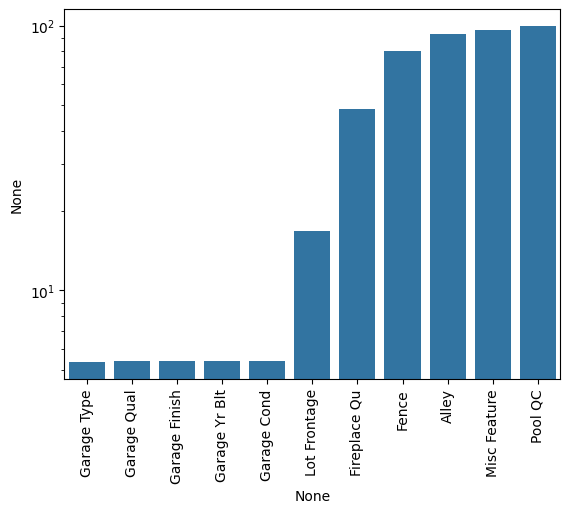

In [31]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.yscale('log')
plt.xticks(rotation=90);

### Fixing data based on Columns

The options to fix missing data column by column are dropping the column altogether or fixing the values using domain knowledge.
* Dropping the feature column is indicated for the case of high percentage of rows missing for that column. Key points:
    * very simple
    * The feature is no longer part of the input data, will not be taken into account. When new data arrives in order to make predictions, this column will not be taken into account, because the model is trained without it and has no coeficient for it.
    * if the feature becomes relevant for predictability in the future, the model has to be substituted.
* Filling in the missing data. Key points:
    * You are making up data, so you are changing the ground truth.
    * You have to find a reasonable estimation to fill the values.
    * You have to apply the same transformation(s) to new incoming data, so you have to save the transformation(s) together with the model.

### Method for filling missing data

Simplest case:
  * Replace all NaN values with a reasonable assumption according to Domain Knowledge.
Harder cases:
  * Use statistical methods based on other columns to fill in the NaN values. 

In [32]:
garage_str_cols = ['Garage Type','Garage Finish','Garage Cond','Garage Qual']

In [34]:
df[garage_str_cols] = df[garage_str_cols].fillna('None')

In [35]:
percent_nan = percent_missing(df)
percent_nan

Garage Yr Blt     5.401709
Lot Frontage     16.752137
Fireplace Qu     48.547009
Fence            80.478632
Alley            93.230769
Misc Feature     96.410256
Pool QC          99.589744
dtype: float64

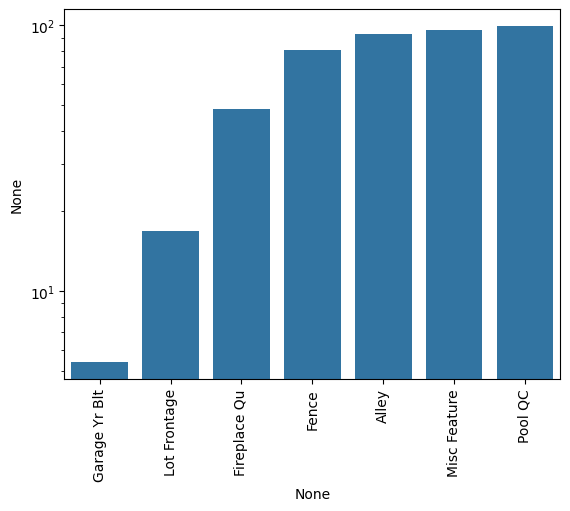

In [36]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.yscale('log')
plt.xticks(rotation=90);

We have now 'Garage Yr Blt' which is a year number. Usually, the dates, years, etc. should not be filled in with 0, since it introduces a big skew in the data. It is more adequate to use an average, the lowest of the values, or the like. In our case we will be assuming that the absence of a garage also removes the significance of all garage data, so we are going to fill its NaN values with 0.

In [37]:
df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0)

In [38]:
# Recalculate % NaN and plot again.
percent_nan = percent_missing(df)
percent_nan

Lot Frontage    16.752137
Fireplace Qu    48.547009
Fence           80.478632
Alley           93.230769
Misc Feature    96.410256
Pool QC         99.589744
dtype: float64

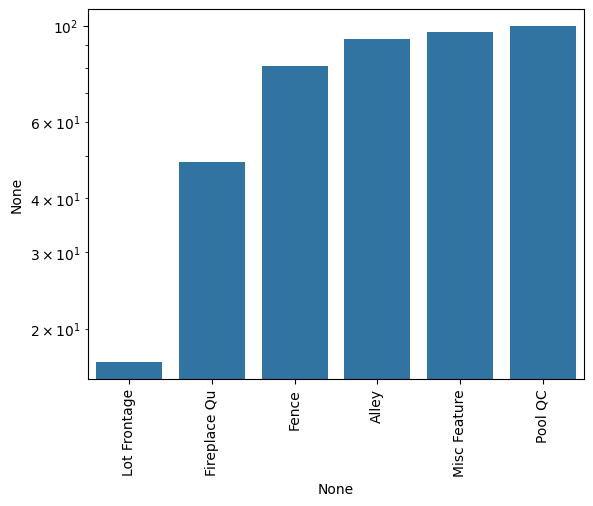

In [39]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.yscale('log')
plt.xticks(rotation=90);

Let's approach first those that are missing a lot of rows. Those will be dropped, since the absence of so high percentage of rows means that the feature columns have little significance.

The case of 'Pool QC' could be considered as the basement, since the description of the feature indicates that NA means no pool, so 'None' could have been a good choice. But for the exercise, let's drop it with the rest of the high percentage of missing data.

In [40]:
df = df.drop(['Fence','Alley','Misc Feature','Pool QC'],axis=1)

In [41]:
# Recalculate % missing and plot
percent_nan = percent_missing(df)
percent_nan

Lot Frontage    16.752137
Fireplace Qu    48.547009
dtype: float64

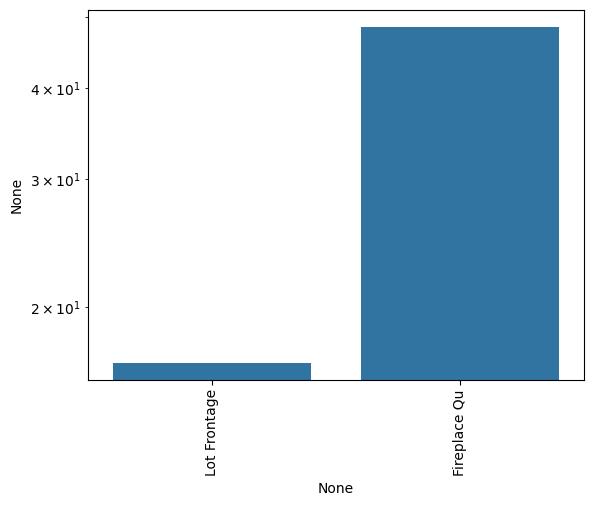

In [42]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.yscale('log')
plt.xticks(rotation=90);

The remaining columns with missing values are in the range where there are a lot of missing values, but they still have enough data to be considered as contributing to the prediction. We need to carefully consider what we have and what might be we are missing.

Investigating the possible values of 'Fireplace Qu', let's see what unique values we do have in the rest of the rows.

In [43]:
df['Fireplace Qu'].value_counts()

Fireplace Qu
Gd    741
TA    600
Fa     75
Po     46
Ex     43
Name: count, dtype: int64

They are string values. Let's look at the description of the feature: NA means no fireplace. So we can safely invent a new value 'None' to indicate there is no fireplace

In [44]:
df['Fireplace Qu'] = df['Fireplace Qu'].fillna('None')

Down to the last column with missing values. 16% missing. Looking into the values, we see that it is a numerical continuous feature.

The meaning of the feature is the length of street section connected to the property: how many feet of street run along the property.

In [46]:
df['Lot Frontage'].value_counts()

Lot Frontage
60.0     276
80.0     137
70.0     133
50.0     116
75.0     105
        ... 
168.0      1
111.0      1
131.0      1
153.0      1
133.0      1
Name: count, Length: 128, dtype: int64

We are going to assume the section of street connected to the property is related to the neighborhood: in the same neighborhood, properties tend to have the same 'Frontage'.

Let's check this assumption with a box plot.

<Axes: xlabel='Lot Frontage', ylabel='Neighborhood'>

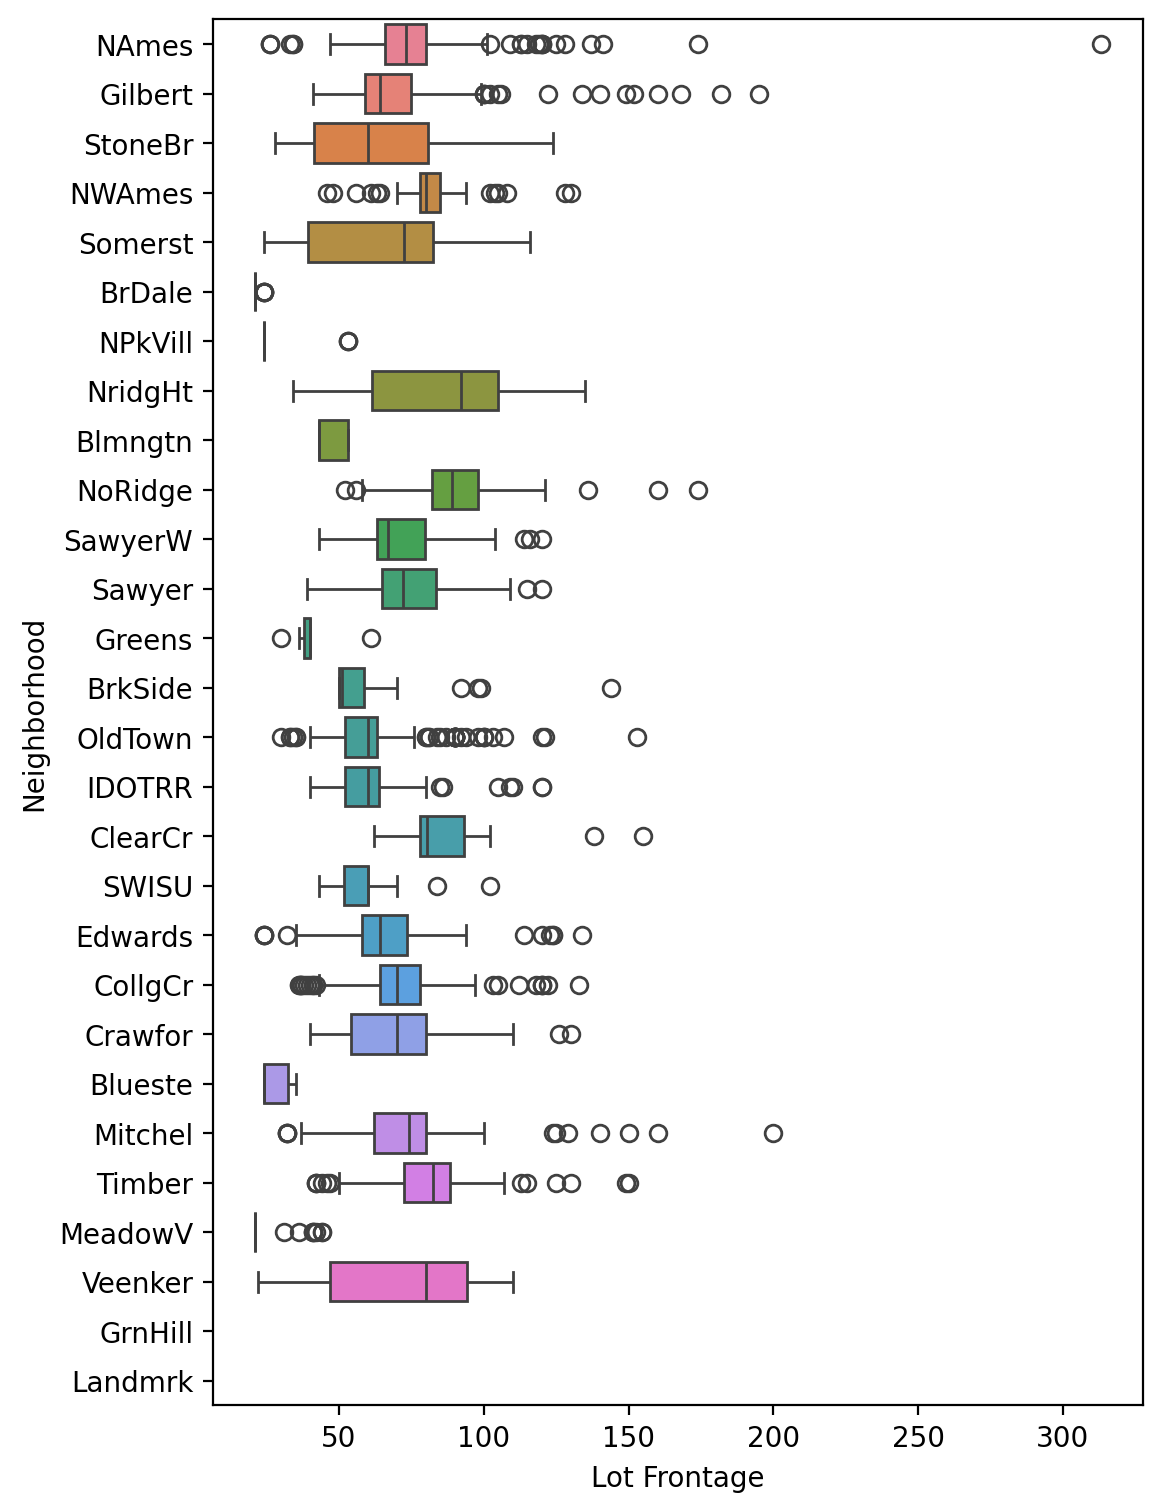

In [52]:
plt.figure(figsize=(6,9), dpi=200)
sns.boxplot(x='Lot Frontage',y='Neighborhood',data=df,orient='h',hue='Neighborhood')

We can fill in the Frontage value based on the Neighborhood, because it doesn't have any missing values.

Let's use the mean in each neighborhood to fill in any NaN.

In [54]:
df.groupby('Neighborhood')['Lot Frontage'].mean()

Neighborhood
Blmngtn    46.900000
Blueste    27.300000
BrDale     21.500000
BrkSide    55.789474
ClearCr    88.150000
CollgCr    71.336364
Crawfor    69.951807
Edwards    64.794286
Gilbert    74.207207
Greens     41.000000
GrnHill          NaN
IDOTRR     62.383721
Landmrk          NaN
MeadowV    25.606061
Mitchel    75.144444
NAmes      75.210667
NPkVill    28.142857
NWAmes     81.517647
NoRidge    91.629630
NridgHt    84.184049
OldTown    61.777293
SWISU      59.068182
Sawyer     74.551020
SawyerW    70.669811
Somerst    64.549383
StoneBr    62.173913
Timber     81.303571
Veenker    72.000000
Name: Lot Frontage, dtype: float64

In [55]:
df.groupby('Neighborhood')['Lot Frontage'].transform(lambda value: value.fillna(value.mean()))

0       141.000000
1        80.000000
2        81.000000
3        93.000000
4        74.000000
           ...    
2922     37.000000
2923     75.144444
2924     62.000000
2925     77.000000
2926     74.000000
Name: Lot Frontage, Length: 2925, dtype: float64

In [56]:
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda value: value.fillna(value.mean()))

In [65]:
# check for null values
df.columns[df.isnull().sum()>0]

Index(['Lot Frontage'], dtype='object')

So only 'Lot Frontage' has any missing values and it has . . .

In [66]:
df['Lot Frontage'].info()

<class 'pandas.core.series.Series'>
Index: 2925 entries, 0 to 2926
Series name: Lot Frontage
Non-Null Count  Dtype  
--------------  -----  
2922 non-null   float64
dtypes: float64(1)
memory usage: 45.7 KB


... 2925 - 2922 = 3 Null values.

In [73]:
df[df['Lot Frontage'].isnull()]['Neighborhood']

2253    GrnHill
2785    Landmrk
2889    GrnHill
Name: Neighborhood, dtype: object

The three rows are indeed pertaining to the neighborhoods that have no average for the frontage.

In [75]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].mean())

In [76]:
#Recalculate % missing
percent_nan = percent_missing(df)
percent_nan

Series([], dtype: float64)

No missing data. DataFrame is clean.